# `ABaCo` demo: Parkinson's disease gut microbiome

This notebook is used as a demo of ABaCo's capabilities on integrating multiple studies with multiple biomes. In this case, the Parkinson's dataset contains samples from the gut microbiome from 5 different studies.

-----
**Data Description:**

- The Parkinson's dataset has been obtained from 9 different studies:

    1. Wallen ZD, Demirkan A, Twa G *et al.* Metagenomics of Parkinson’s disease implicates the gut microbiome in multiple disease mechanisms. *Nat Commun* 2022;13, DOI: 10.1038/s41467-022-34667-x.

    2. Boktor JC, Sharon G, Verhagen Metman LA *et al.* Integrated Multi‐Cohort Analysis of the Parkinson’s Disease Gut Metagenome. *Movement Disorders* 2023;38:399–409.

    3. Jo S, Kang W, Hwang YS *et al.* Oral and gut dysbiosis leads to functional alterations in Parkinson’s disease. *npj Parkinsons Dis* 2022;8, DOI: 10.1038/s41531-022-00351-6.

    4. Nishiwaki H, Ueyama J, Ito M *et al.* Meta-analysis of shotgun sequencing of gut microbiota in Parkinson’s disease. *npj Parkinsons Dis* 2024;10, DOI: 10.1038/s41531-024-00724-z.

    5. Bedarf JR, Hildebrand F, Coelho LP *et al.* Functional implications of microbial and viral gut metagenome changes in early stage L-DOPA-naïve Parkinson’s disease patients. *Genome Med* 2017;9, DOI: 10.1186/s13073-017-0428-y.

    6. Duru IC, Lecomte A, Shishido TK *et al.* Metagenome-assembled microbial genomes from Parkinson’s disease fecal samples. *Sci Rep* 2024;14, DOI: 10.1038/s41598-024-69742-4.

    7. Qian Y, Yang X, Xu S *et al.* Gut metagenomics-derived genes as potential biomarkers of Parkinson’s disease. *Brain* 2020;143:2474–89.

    8. Mao L, Zhang Y, Tian J *et al.* Cross-Sectional Study on the Gut Microbiome of Parkinson’s Disease Patients in Central China. *Front Microbiol* 2021;12, DOI: 10.3389/fmicb.2021.728479.

    9. Chen S-J, Chen C-C, Liao H-Y *et al.* Association of Fecal and Plasma Levels of Short-Chain Fatty Acids With Gut Microbiota and Clinical Severity in Patients With Parkinson Disease. *Neurology* 2022;98, DOI: 10.1212/wnl.0000000000013225.

- The taxonomic profiles of every study was obtained from Metalog ([Kuhn et al., 2025](https://doi.org/10.1093/nar/gkaf1118)), which were obtained using mOTUs 3.0 profiler.

- Dataset with all studies are composed of a total of 867 OTUs and 1,615 samples. As we are trying to integrate studies, the technical source of variation is the study of provenence, while the biological source of variation would be the condition (Parkinson's disease v.s Control).

-----
**Goals:**

The aim is to integrate the 9 studies while preserving key distinctions from the two patient states (Parkinson's v.s. Healthy).


## Dataloading 

In [1]:
from abaco.dataloader import DataPreprocess, one_hot_encoding

# Load Parkinson's disease dataset
path_to_dataset = 'data/dataset_parkinson.csv'
batch_col = "study_code"
bio_col = "phenotype"
id_col = "samples"

# Convert data path into compatible pd.DataFrame
df_parkinson = DataPreprocess(
    path_to_dataset,
    factors = [
        id_col,
        batch_col,
        bio_col
    ]
).dropna()

# see if there are 3 categorical and n numeric columns (should be an extra column for location)
print(df_parkinson.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1615 entries, 0 to 1642
Columns: 871 entries, samples to location
dtypes: category(3), int64(867), object(1)
memory usage: 10.8+ MB
None


## Dataset analysis

### Supplementary functions (to be added on source)

In [2]:
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova
from skbio.stats.ordination import pcoa
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
import numpy as np

# Auxiliary
def permanova_ait(df, sample_label, group_label):
    samples = df[sample_label].values
    groups = df[group_label].values
    clr_data = df.select_dtypes(include = "number").values

    aitch = pdist(clr_data, metric = "euclidean")
    dist_mat = squareform(aitch)
    dm = DistanceMatrix(dist_mat, ids=samples)

    res_ait = permanova(distance_matrix=dm, grouping=groups)

    res_ait["R2"] = (
        res_ait["test statistic"]
        * (len(np.unique(groups)) - 1)
        / (
            res_ait["test statistic"] * (len(np.unique(groups)) - 1)
            + (len(samples) - len(np.unique(groups)))
        )
    )
    return res_ait

def pcoa_aitchison(df, sample_label, batch_label, bio_label):
    df_otu = df.select_dtypes(include="number")
    dist = pdist(df_otu, "euclidean")
    dist = squareform(dist)

    pcoa_res = pcoa(dist)
    explained = (pcoa_res.proportion_explained * 100).round(1)
    explained_dict = {"PC1": explained[0], "PC2": explained[1]}
    df_pcoa = pd.DataFrame(pcoa_res.samples[["PC1","PC2"]], columns=["PC1","PC2"])
    df_pcoa.index = (
        df.index
    )
    df_pcoa[[sample_label, batch_label, bio_label]] = df[[sample_label, batch_label, bio_label]]
    return df_pcoa, explained_dict

def plot_pcoa_2(
    df_pcoa,
    group_col,
    df,
    sample_label,
    ax,
    explained,
    palette=None,
    xlim=None,
    ylim=None,
    marginal_size="20%",     # size of marginals relative to main
    marginal_pad=0.1,         # padding between main and marginals
    kde_bw_adjust=1.0,        # bandwidth scaling for KDE
    alpha_kde=0.5,            # fill transparency for KDE areas
    title=None,               # optional title above the top density plot
    show_legend=True          # whether to draw the legend
):
    # compute PERMANOVA R2
    perma_r2 = permanova_ait(df, sample_label, group_col)["R2"]

    # set up axes divider for marginals
    divider = make_axes_locatable(ax)
    ax_top   = divider.append_axes("top",    size=marginal_size, pad=marginal_pad, sharex=ax)
    ax_right = divider.append_axes("right",  size=marginal_size, pad=marginal_pad, sharey=ax)

    # hide the marginal axes completely (no ticks, no spines)
    ax_top.axis('off')
    ax_right.axis('off')

    groups = df_pcoa[group_col].unique()
    colors = palette or plt.cm.tab10.colors

    handles = []
    labels  = []

    for i, grp in enumerate(groups):
        sub = df_pcoa[df_pcoa[group_col] == grp]
        x = sub['PC1'].values
        y = sub['PC2'].values
        c = colors[i % len(colors)]

        # main scatter
        pts = ax.scatter(x, y, label=str(grp), alpha=0.7, color=c)
        handles.append(pts)
        labels.append(str(grp))

        # marginal KDEs (axes are off so only the filled area shows)
        sns.kdeplot(
            x=x, ax=ax_top, bw_adjust=kde_bw_adjust,
            fill=True, alpha=alpha_kde, color=c, linewidth=1.5
        )
        sns.kdeplot(
            y=y, ax=ax_right, bw_adjust=kde_bw_adjust,
            fill=True, alpha=alpha_kde, color=c, linewidth=1.5
        )

        # 95% confidence ellipse
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        width, height = 2 * np.sqrt(vals * 5.991)
        angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
        ell = Ellipse(
            xy=(x.mean(), y.mean()),
            width=width, height=height,
            angle=angle, edgecolor=c, facecolor='none', lw=2
        )
        ax.add_patch(ell)

    # add title above the top density plot
    if title:
        ax_top.set_title(title, pad=10, fontsize=16)

    # optionally draw legend on top density axis
    if show_legend:
        ax_top.legend(
            handles, labels,
            title=group_col,
            bbox_to_anchor=(1.02, 1), loc='upper left',
            frameon=False,
            fontsize=14,
            title_fontsize=16,
        )

    # main axis formatting
    ax.set_xlabel(f"PC1 ({explained['PC1']:.1f}%)", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained['PC2']:.1f}%)", fontsize=12)
    ax.text(
        0.99, 0.99,
        f"PERMANOVA R² ({group_col}): {perma_r2:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize="small"
    )
    ax.set_aspect('equal')

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

### PCoA plots

/tmp/ipykernel_3962763/2689478418.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


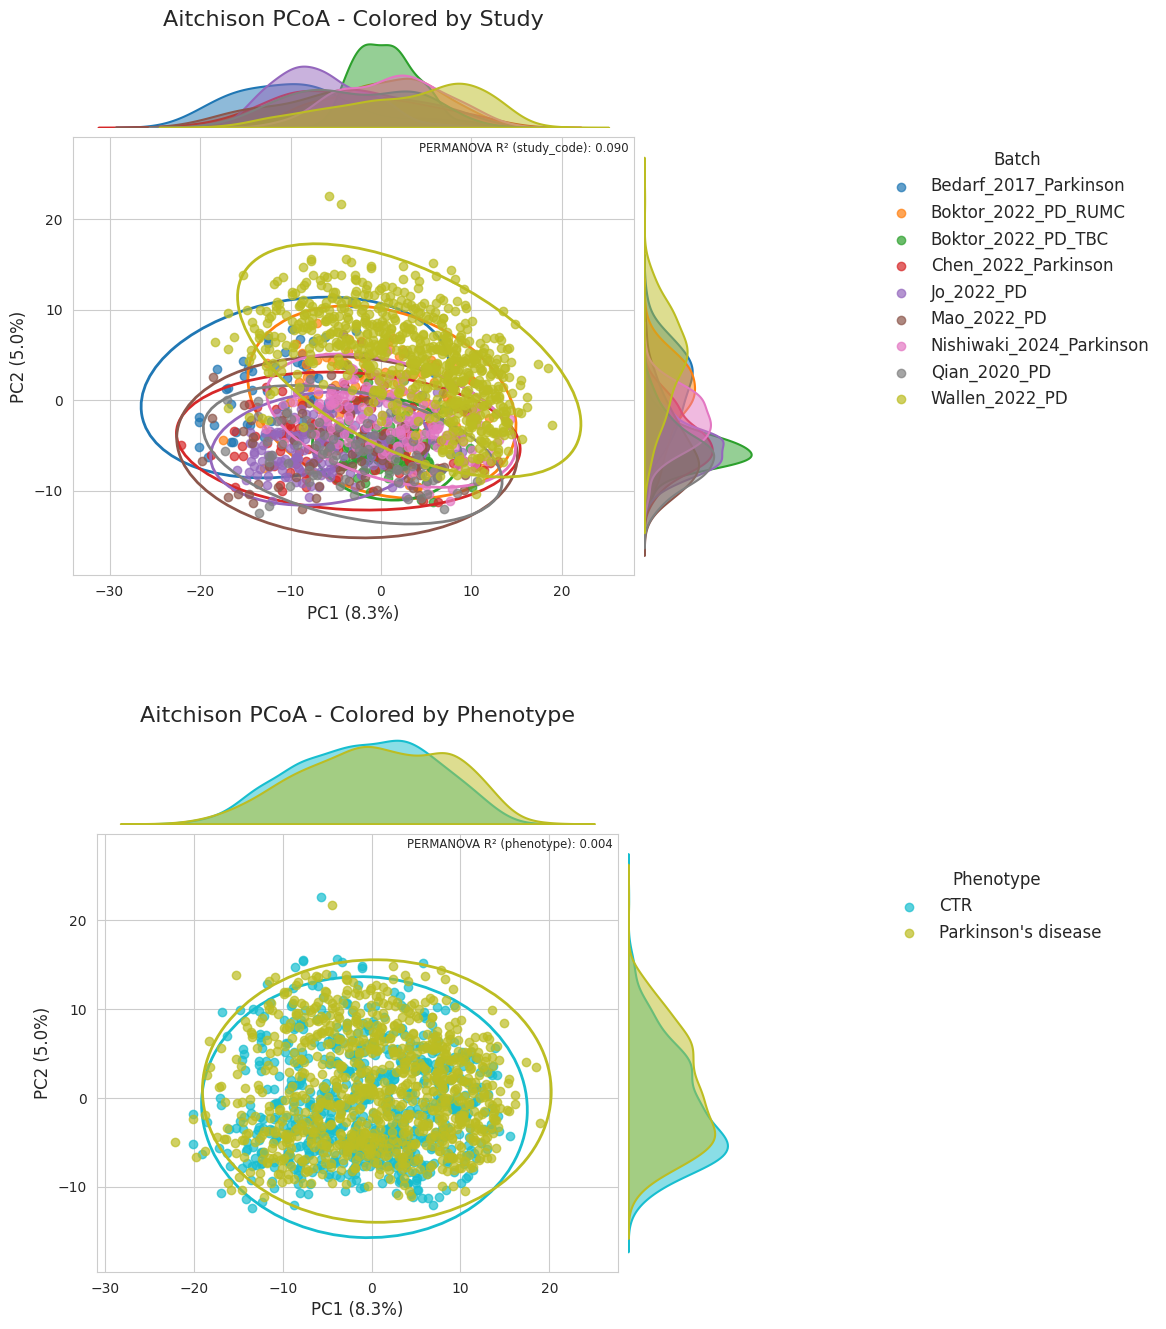

In [ ]:
# Define figure
from abaco.dataloader import DataTransform

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])

data_clr = DataTransform(df_parkinson, factors=[id_col, batch_col, bio_col], count=True)

data_pcoa, data_exp = pcoa_aitchison(
    data_clr,
    sample_label=id_col,
    batch_label=batch_col,
    bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Batch",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.8, 0.82),
    fontsize=12,
    title_fontsize=12
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Phenotype",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.78, 0.37),
    fontsize=12,
    title_fontsize=12
)

fig.subplots_adjust(right=0.85)

plt.show()

We can see that the main source of variation comes from the study and not that much from the disease. ABaCo's evaluation of integrating these studies then would be focused on not adding biological biases while doing it.

## Using `ABaCo`

We are going to create the class `abaco.metaABaCo()` and pass the required parameters for training the model into the data. 

In [18]:
from abaco.ABaCo import metaABaCo
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create ABaCo model
abaco_model = metaABaCo(
    data = df_parkinson,
    n_bios = 2,
    bio_label = bio_col,
    n_batches=9,
    batch_label=batch_col,
    n_features=df_parkinson.select_dtypes(include="number").shape[1],
    prior="VMM",
    device=device,
    epochs=[1000, 2000, 1000] # [1000, 2000, 1000]
)

abaco_model.fit(seed=42,
                w_cluster_penalty=0.1, # 0.1
                phase_1_vae_lr=1e-3, # 1e-3
                phase_2_vae_lr=1e-3, # 1e-3
                phase_3_vae_lr=1e-7, #1e-7
                adv_lr=1e-4, # 1e-4
                disc_lr=1e-4) # 1e-4

Training: VAE for learning meaningful embeddings: 100%|██████████| 1000/1000 [00:46<00:00, 21.67it/s, bio_penalty=0.4833, clustering_loss=0.0288, elbo=846.4944, epoch=999/1001, vae_loss=847.0065]
Training: Embeddings batch effect correction using adversrial training: 100%|██████████| 2000/2000 [01:40<00:00, 19.82it/s, adv_loss=-1.7297, bio_penalty=0.4482, clustering_loss=0.0000, disc_loss=1.7297, elbo=734.8683, epoch=1999/2001, vae_loss=735.3165]
Training: VAE decoder with masked batch labels: 100%|██████████| 1000/1000 [00:34<00:00, 29.25it/s, cycle_loss=0.0000, epoch=1000/1000, vae_loss=1559.7037]


### PCoA after correction

/tmp/ipykernel_3962763/2689478418.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  explained_dict = {"PC1": explained[0], "PC2": explained[1]}


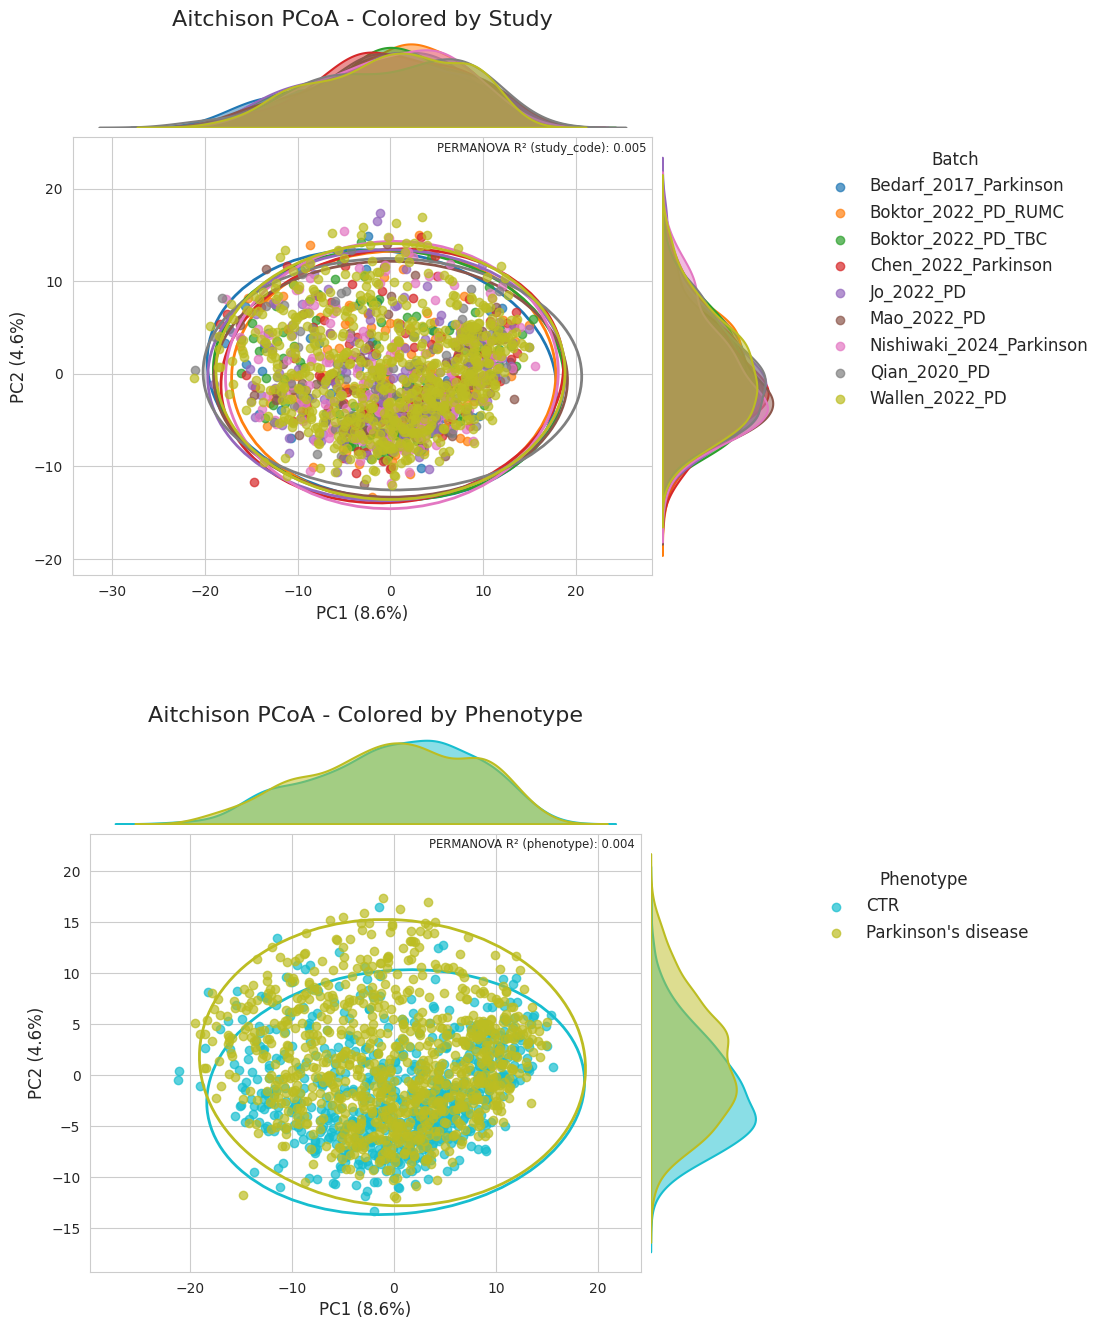

In [21]:
# Reconstruct the dataset using the trained ABaCo model
corrected_dataset = abaco_model.correct(seed=42)

sns.set_style("whitegrid")
fig = plt.figure(figsize=(24, 16))
fig.suptitle("", fontsize=16, y=0.97)

gs = GridSpec(2, 1, figure=fig, wspace=0.4, hspace=0.3)

top_palette = sns.color_palette("tab10", n_colors=9)
bottom_palette = sns.color_palette("tab10", n_colors=10)[::-1][:9]

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[1,0])

corrected_data_clr = DataTransform(corrected_dataset, factors=[id_col, batch_col, bio_col], count=True)

data_pcoa, data_exp = pcoa_aitchison(
    corrected_data_clr,
    sample_label=id_col,
    batch_label=batch_col,
    bio_label=bio_col
)

plot_pcoa_2(
    data_pcoa,
    group_col=batch_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax1,
    explained=data_exp,
    palette=top_palette,
    title="Aitchison PCoA - Colored by Study",
    show_legend=False
)

handles, labels = ax1.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Batch",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.77, 0.82),
    fontsize=12,
    title_fontsize=12
)

plot_pcoa_2(
    data_pcoa,
    group_col=bio_col,
    df=corrected_data_clr,
    sample_label=id_col,
    ax=ax2,
    explained=data_exp,
    palette=bottom_palette,
    title="Aitchison PCoA - Colored by Phenotype",
    show_legend=False
)

handles, labels = ax2.get_legend_handles_labels()

fig.legend(
    handles, labels,
    title="Phenotype",
    loc = "upper right",
    frameon = False,
    bbox_to_anchor = (0.745, 0.37),
    fontsize=12,
    title_fontsize=12
)

fig.subplots_adjust(right=0.85)

plt.show()

## Performance metrics

To finalize this analysis, we can compute the performance metrics on the batch correction task using `abaco.metrics` different functions:

In [27]:
import abaco.metrics as metrics

print("kBET results before batch correction:")
print(metrics.kBET(data_clr, batch_col))
print("\niLISI results before batch correction:")
print(metrics.iLISI_norm(data_clr, batch_col))
print("\nbatch ASW results before batch correction:")
print(1 - metrics.ASW(data_clr, batch_col))
print("\nbatch ARI results before batch correction:")
print(1 - metrics.ARI(data_clr, batch_col))

print("\n\nkBET results after batch correction:")
print(metrics.kBET(corrected_data_clr, batch_col))
print("\niLISI results after batch correction:")
print(metrics.iLISI_norm(corrected_data_clr, batch_col))
print("\nbatch ASW results after batch correction:")
print(1 - metrics.ASW(corrected_data_clr, batch_col))
print("\nbatch ARI results after batch correction:")
print(1 - metrics.ARI(corrected_data_clr, batch_col))

kBET results before batch correction:
0.007430340557275541

iLISI results before batch correction:
0.20374280987445953

batch ASW results before batch correction:
1.0912639737358285

batch ARI results before batch correction:
0.8022331475013699


kBET results after batch correction:
0.7777089783281734

iLISI results after batch correction:
0.4959767970968545

batch ASW results after batch correction:
1.0198911298066378

batch ARI results after batch correction:
0.9998250708087281
